# Assignment Topic: Predicting Customer Churn + Hyperparameter Tuning

## Persiapan Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("churn.csv")

# Lihat struktur dan missing values
print("Missing values:\n", df.isnull().sum())
df.info()
df.head()

Missing values:
 customerID           9
Gender              16
SeniorCitizen       12
Partner             16
Dependents          19
Tenure              17
Contract            13
PaperlessBilling    13
PaymentMethod       11
MonthlyCharges      10
TotalCharges         0
Churn                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7046 entries, 0 to 7045
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7037 non-null   object 
 1   Gender            7030 non-null   object 
 2   SeniorCitizen     7034 non-null   float64
 3   Partner           7030 non-null   object 
 4   Dependents        7027 non-null   object 
 5   Tenure            7029 non-null   float64
 6   Contract          7033 non-null   object 
 7   PaperlessBilling  7033 non-null   object 
 8   PaymentMethod     7035 non-null   object 
 9   MonthlyCharges    7036 non-null   float64
 10  TotalCharges      

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,NaN,No,1.0,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34.0,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0.0,No,No,2.0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45.0,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,No,No,2.0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

In [2]:
df.isna().sum()

customerID           9
Gender              16
SeniorCitizen       12
Partner             16
Dependents          19
Tenure              17
Contract            13
PaperlessBilling    13
PaymentMethod       11
MonthlyCharges      10
TotalCharges         0
Churn                0
dtype: int64

In [3]:
# Hapus kolom ID karena tidak relevan
df.drop(columns=['customerID'], inplace=True)

In [4]:
# Drop baris yang memiliki missing values
df.dropna(inplace=True)

In [5]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df.isna().sum()

Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Analisis Korelasi dan Seleksi fitur

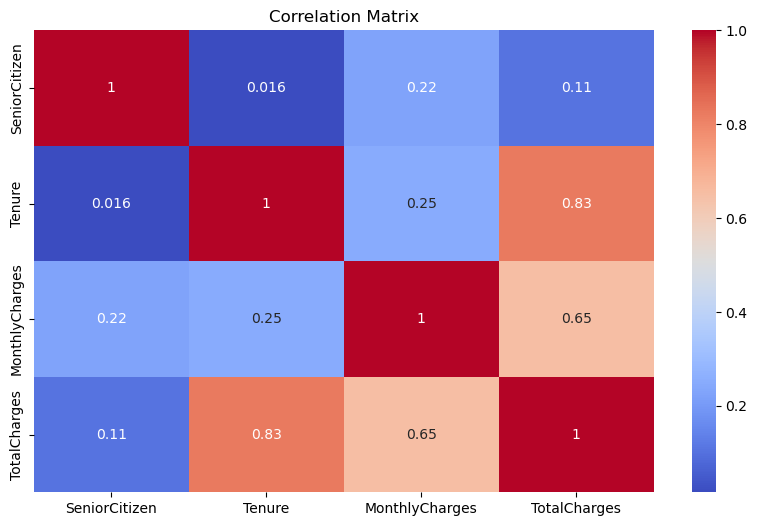

In [7]:
# Korelasi antar fitur numerik
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [9]:
# drop total charges karena tidak relevan untuk analisis ini
df.drop(columns=['TotalCharges'], inplace=True)

### Analisis Korelasi & Seleksi Fitur

Berdasarkan korelasi antar fitur numerik, kita temukan bahwa:

- `Tenure` dan `TotalCharges` memiliki korelasi tinggi (**0.83**)
- Hal ini mengindikasikan adanya **multikolinearitas**

Karena `TotalCharges` merupakan hasil dari `MonthlyCharges × Tenure`, maka fitur tersebut **berpotensi redundant** dan akan **dihapus** agar model tidak bingung dengan informasi ganda.

## Pengolahan data kategorikal

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,Tenure,MonthlyCharges,Gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
1,0,34.0,56.95,True,False,False,True,False,False,False,False,True,False
2,0,2.0,53.85,True,False,False,False,False,True,False,False,True,True
3,0,45.0,42.30,True,False,False,True,False,False,False,False,False,False
4,0,2.0,70.70,False,False,False,False,False,True,False,True,False,True
5,0,8.0,99.65,False,False,False,False,False,True,False,True,False,True


## Pemilihan Metrik Evaluasi

Karena ini adalah masalah klasifikasi churn (Yes/No), metrik yang digunakan adalah:

- **Accuracy** → seberapa banyak prediksi yang benar
- **Precision & Recall** → penting saat churn memiliki dampak bisnis besar
- **F1 Score** → trade-off antara precision dan recall


## Split Data

In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Hyperparameter Tuning dengan RandomForest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Definisikan model
rf = RandomForestClassifier(random_state=42)

# Definisikan parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10]
}

# Grid search dengan cross-validation
grid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

# Tampilkan hasil terbaik
print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 100}


## Evaluasi Model

In [13]:
y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[948  70]
 [209 157]]
              precision    recall  f1-score   support

       False       0.82      0.93      0.87      1018
        True       0.69      0.43      0.53       366

    accuracy                           0.80      1384
   macro avg       0.76      0.68      0.70      1384
weighted avg       0.79      0.80      0.78      1384



## Kesimpulan

- Dataset telah dibersihkan dan diolah dengan baik.
- Model terbaik menggunakan Random Forest dengan kombinasi hyperparameter hasil GridSearchCV.
- Metrik evaluasi menunjukkan performa model cukup baik dalam memprediksi churn.
- Model bisa dioptimalkan lebih lanjut dengan teknik lain seperti feature engineering atau data balancing (jika perlu).